In [2]:
# ============================================================
# LESSON 4: NewsAPI Data Collection
# Goal: Collect news articles for each product
# ============================================================

import requests        # to call the NewsAPI URL
import pandas as pd    # to organize data into tables
import matplotlib.pyplot as plt  # to make charts
import warnings        # to hide annoying warnings
warnings.filterwarnings("ignore")  # hide all warnings

# Full path to save data files — never change this
DATA_PATH = "/Users/sanjana/Desktop/Hype-Predictor/Data"

# Your NewsAPI key — paste yours here
NEWS_API_KEY = ""

# The 5 products we are tracking
PRODUCTS = ["PS5 Pro", "iPhone 17", "Air Jordan 11", "Owala FreeSip", "Nvidia RTX 5090"]

print("✅ Setup complete!")


✅ Setup complete!


In [4]:
# ============================================================
# FUNCTION: fetch_news
# What it does: calls NewsAPI and returns article data
# ============================================================

def fetch_news(product):
    # Base URL for NewsAPI's "everything" endpoint
    url = "https://newsapi.org/v2/everything"
    
    # Parameters we send with the request (like a search form)
    params = {
        "q": product,           # search keyword = product name
        "language": "en",       # English articles only
        "sortBy": "publishedAt",# newest articles first
        "pageSize": 100,        # get 100 articles max
        "apiKey": NEWS_API_KEY  # your personal API key
    }
    
    # Make the actual API call
    response = requests.get(url, params=params)
    
    # Convert response to Python dictionary
    data = response.json()
    
    # Extract articles list from response
    articles = data.get("articles", [])
    
    print(f"  Found {len(articles)} articles for: {product}")
    
    # Return both articles and total count
    return articles, data.get("totalResults", 0)

In [6]:
# ============================================================
# TEST: Run on one product before all 5
# ============================================================

print("Testing on PS5 Pro...")

# Call the function for just one product
test_articles, test_total = fetch_news("PS5 Pro")

# Show what one article looks like
print(f"\nTotal articles available: {test_total}")
print(f"\nSample article:")
print(f"  Title  : {test_articles[0]['title']}")
print(f"  Source : {test_articles[0]['source']['name']}")
print(f"  Date   : {test_articles[0]['publishedAt']}")

Testing on PS5 Pro...
  Found 98 articles for: PS5 Pro

Total articles available: 433

Sample article:
  Title  : What caused Starfield crashes on PS5? #gaming
  Source : Alltoc.com
  Date   : 2026-04-14T06:02:25Z


In [8]:
# ============================================================
# COLLECT: Loop through all 5 products
# ============================================================

# Empty list to store all rows
all_rows = []

# Loop through each product
for product in PRODUCTS:
    print(f"\nFetching news for: {product}")
    
    # Call our function
    articles, total = fetch_news(product)
    
    # Count unique sources (how many different news sites)
    sources = set()  # set = no duplicates allowed
    
    # Loop through each article
    for article in articles:
        source_name = article["source"]["name"]  # get source name
        sources.add(source_name)                 # add to set (auto-deduplicates)
    
    # Build one summary row for this product
    row = {
        "product": product,
        "article_count": len(articles),      # how many articles we got
        "total_available": total,            # how many exist in total
        "unique_sources": len(sources),      # how many different news sites
        "source_names": ", ".join(sources)   # all source names as text
    }
    
    # Add this row to our list
    all_rows.append(row)

print("\n✅ Done collecting all products!")


Fetching news for: PS5 Pro
  Found 98 articles for: PS5 Pro

Fetching news for: iPhone 17
  Found 99 articles for: iPhone 17

Fetching news for: Air Jordan 11
  Found 96 articles for: Air Jordan 11

Fetching news for: Owala FreeSip
  Found 27 articles for: Owala FreeSip

Fetching news for: Nvidia RTX 5090
  Found 100 articles for: Nvidia RTX 5090

✅ Done collecting all products!


In [10]:
# ============================================================
# SAVE: Convert to DataFrame and save
# ============================================================

# Convert list of rows into a DataFrame (table)
df_news = pd.DataFrame(all_rows)

# Show the table
print(df_news[["product", "article_count", "unique_sources"]])

# Build full save path
save_path = f"{DATA_PATH}/news_data.csv"

# Save to CSV
df_news.to_csv(save_path, index=False)  # index=False = don't save row numbers

print(f"\n✅ Saved: news_data.csv")

           product  article_count  unique_sources
0          PS5 Pro             98              37
1        iPhone 17             99              49
2    Air Jordan 11             96              65
3    Owala FreeSip             27               9
4  Nvidia RTX 5090            100              30

✅ Saved: news_data.csv


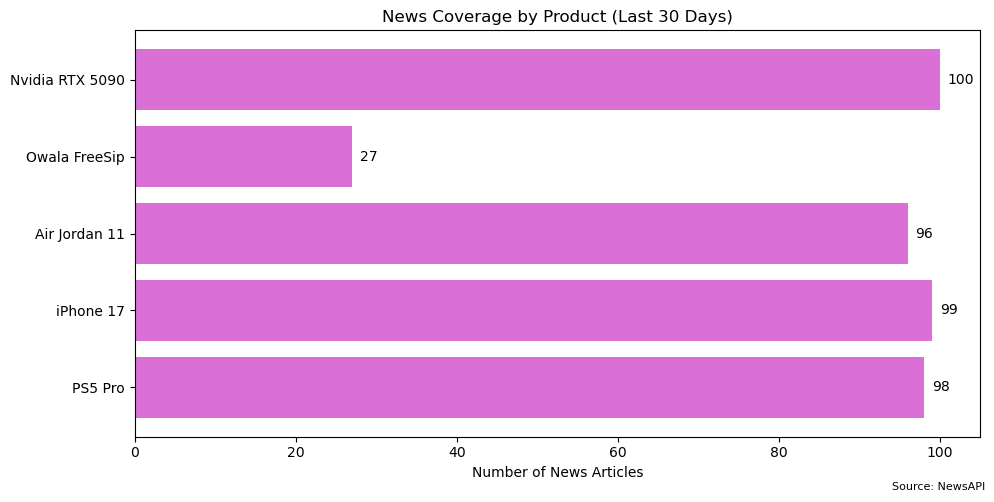

✅ Saved: news_chart.png


In [14]:
# ============================================================
# CHART: Bar chart of article count per product
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))  # create figure

# Draw horizontal bars
ax.barh(df_news["product"], df_news["article_count"], color="orchid")

# Labels and title
ax.set_xlabel("Number of News Articles")
ax.set_title("News Coverage by Product (Last 30 Days)")

# Add value labels on each bar
for i, val in enumerate(df_news["article_count"]):
    ax.text(val + 1, i, str(val), va="center")  # write number at end of bar

# Credit line at bottom
plt.figtext(0.99, 0.01, "Source: NewsAPI", ha="right", fontsize=8)

plt.tight_layout()

# Save chart
plt.savefig(f"{DATA_PATH}/news_chart.png", dpi=150)
plt.show()

print("✅ Saved: news_chart.png")